# VK Ads Auction Forecasting: защита решения

Цель ноутбука: показать полный путь решения от устройства задачи до финальной модели, объяснить генерацию признаков и наглядно сравнить ошибку разных подходов.

Основная идея решения: не заменять механику аукциона обычной ML-моделью, а сначала построить сильный replay-бейзлайн по прошлому месяцу, затем обучить ML-модель калибровать его ошибку.

## 1. Импорты и загрузка данных

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor

ROOT = Path.cwd()
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / 'src'))

from metrics import get_smoothed_mean_log_accuracy_ratio, get_smoothed_log_mape_column_value
from ml_baseline import EPSILON, RANDOM_STATE, TARGET_COLUMNS, transform_target

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
users = pd.read_csv(ROOT / 'users.tsv', sep='\t')
history = pd.read_csv(ROOT / 'history.tsv', sep='\t')
validate = pd.read_csv(ROOT / 'validate.tsv', sep='\t')
answers = pd.read_csv(ROOT / 'validate_answers.tsv', sep='\t')[TARGET_COLUMNS]

data_overview = pd.DataFrame({
    'table': ['users', 'history', 'validate', 'validate_answers'],
    'rows': [len(users), len(history), len(validate), len(answers)],
    'columns': [users.shape[1], history.shape[1], validate.shape[1], answers.shape[1]],
})
data_overview

,table,rows,columns
0,users,27769,4
1,history,1147857,4
2,validate,1008,6
3,validate_answers,1008,3


## 2. Что нужно предсказывать

Для каждой рекламной кампании из `validate.tsv` нужно предсказать три доли аудитории:

- `at_least_one`: пользователь увидел объявление хотя бы 1 раз;
- `at_least_two`: хотя бы 2 раза;
- `at_least_three`: хотя бы 3 раза.

Важные правила задачи:

- если наша ставка `cpm` выше ставки конкурента, показ выигрывается с вероятностью `1.0`;
- если ставка равна максимальной ставке, вероятность выигрыша `0.5`;
- внутри одной пользовательской сессии одно и то же объявление повторно не показывается;
- новая сессия начинается после отсутствия показов в течение 6 часов.

Поэтому задача не является чисто табличной: в ней явно задана механика аукциона и сессий.

## 3. Первичный анализ данных

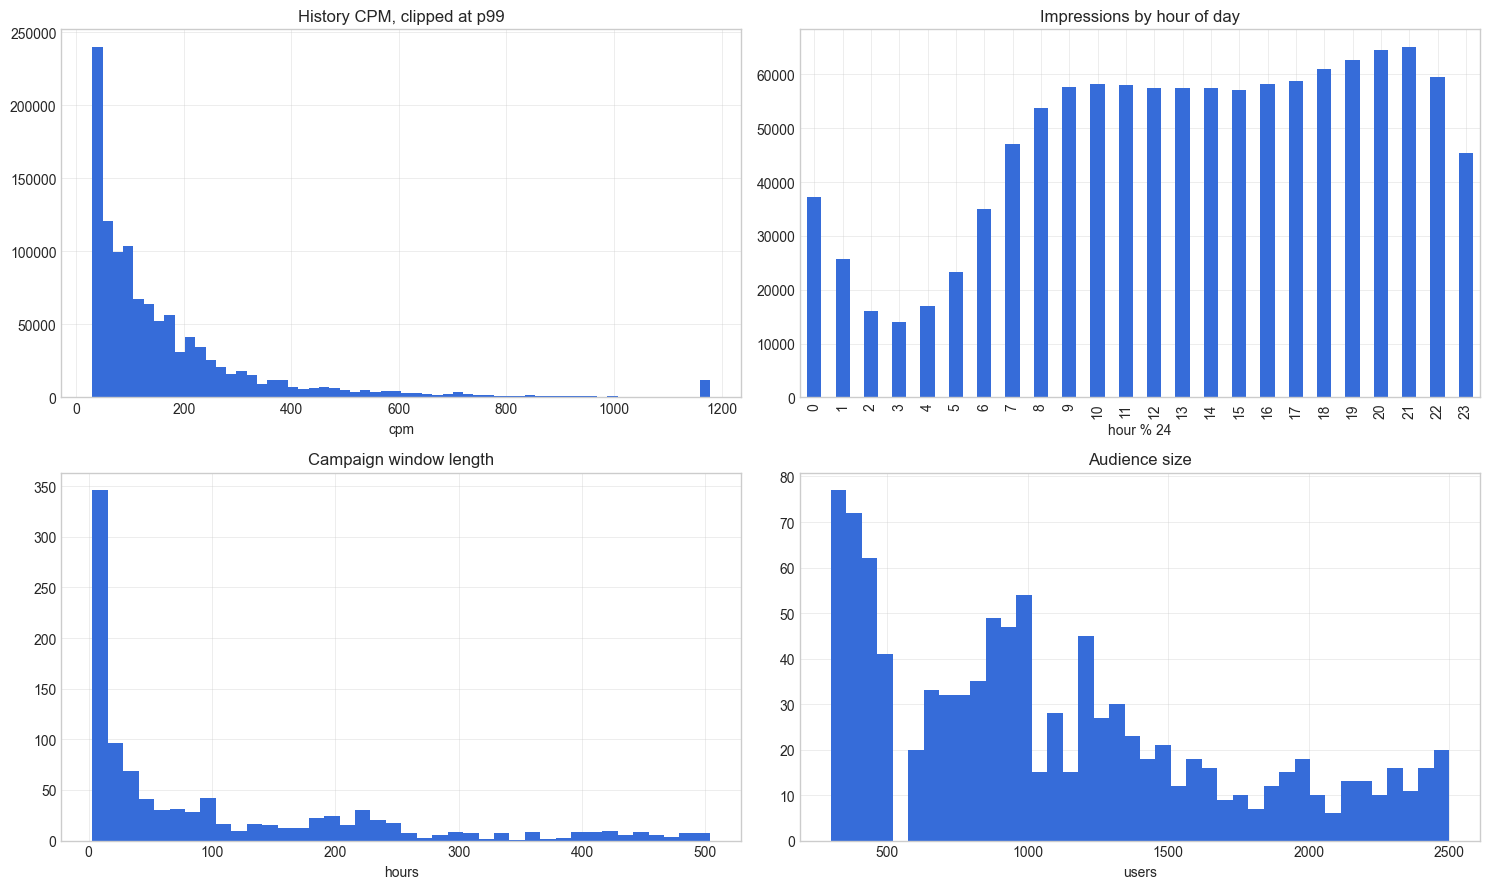

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

history['cpm'].clip(upper=history['cpm'].quantile(0.99)).hist(bins=60, ax=axes[0, 0])
axes[0, 0].set_title('History CPM, clipped at p99')
axes[0, 0].set_xlabel('cpm')

(history['hour'] % 24).value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Impressions by hour of day')
axes[0, 1].set_xlabel('hour % 24')

(validate['hour_end'] - validate['hour_start'] + 1).hist(bins=40, ax=axes[1, 0])
axes[1, 0].set_title('Campaign window length')
axes[1, 0].set_xlabel('hours')

validate['audience_size'].hist(bins=40, ax=axes[1, 1])
axes[1, 1].set_title('Audience size')
axes[1, 1].set_xlabel('users')

plt.tight_layout()

In [4]:
pd.DataFrame({
    'history_hour_min': [history['hour'].min()],
    'history_hour_max': [history['hour'].max()],
    'validate_hour_start_min': [validate['hour_start'].min()],
    'validate_hour_start_max': [validate['hour_start'].max()],
    'history_users': [history['user_id'].nunique()],
    'all_users': [users['user_id'].nunique()],
    'publishers': [history['publisher'].nunique()],
})

,history_hour_min,history_hour_max,validate_hour_start_min,validate_hour_start_max,history_users,all_users,publishers
0,3,1490,747,1485,25536,27769,21


## 4. Общая схема предобработки и генерации признаков

Перед обучением модели сырые таблицы не используются напрямую. Сначала мы строим отдельную матрицу признаков `features_validate.tsv`: одна строка `validate.tsv` превращается в один вектор признаков кампании.

Общая схема пайплайна:

`users.tsv + history.tsv + validate.tsv` -> `src/build_features.py` / `prepare_features_for_tasks` -> `features_validate.tsv`

Затем отдельно считается симуляционный прогноз:

`history.tsv + validate.tsv` -> `src/shift_replay_baseline.py` -> `shift_replay_predictions.tsv`

На этапе ML эти два файла объединяются:

`features_validate.tsv + shift_replay_predictions.tsv` -> `features_full` -> residual-модель калибровки

Это важно подчеркнуть: модель обучается не на исходных строках `validate.tsv`, а на расширенном файле признаков, куда заранее добавлена вся созданная нами информация об аудитории, площадках, свежей истории и replay-прогнозе.

Группы признаков:

1. **Параметры кампании**: `cpm`, длина окна, размер аудитории, число площадок, час начала и окончания.
2. **Агрегаты аудитории**: средний возраст, пол, город, историческая активность пользователей, средние ставки в их истории.
3. **Агрегаты площадок**: объем показов, число пользователей, квантили `cpm`, активность по часам.
4. **Свежая история за 31 день**: активность выбранной аудитории и выбранных площадок перед стартом кампании.
5. **Пересечение аудитории и площадок**: сколько показов было именно у пользователей кампании именно на выбранных площадках.
6. **Shift replay**: прогноз, полученный симуляцией кампании на таком же временном окне предыдущего месяца.

In [5]:
features = pd.read_csv(ROOT / 'features_validate.tsv', sep='\t')
shift_replay = pd.read_csv(ROOT / 'shift_replay_predictions.tsv', sep='\t').rename(columns={
    'at_least_one': 'shift_replay_at_least_one',
    'at_least_two': 'shift_replay_at_least_two',
    'at_least_three': 'shift_replay_at_least_three',
})
features_full = pd.concat([features, shift_replay], axis=1)

def feature_group(name: str) -> str:
    if name.startswith('shift_replay'):
        return 'shift_replay'
    if name.startswith('recent_31d_intersection'):
        return 'recent_intersection'
    if name.startswith('recent_31d_audience'):
        return 'recent_audience'
    if name.startswith('recent_31d_publishers'):
        return 'recent_publishers'
    if name.startswith('audience_'):
        return 'audience_aggregates'
    if name.startswith('publisher_'):
        return 'publisher_aggregates'
    if name.startswith('cpm') or name == 'log_cpm':
        return 'cpm'
    if 'hour' in name or 'window' in name:
        return 'time_window'
    return 'campaign'

feature_catalog = pd.DataFrame({
    'feature': features_full.columns,
    'group': [feature_group(c) for c in features_full.columns],
    'missing': features_full.isna().sum().to_numpy(),
    'nunique': features_full.nunique(dropna=False).to_numpy(),
})

feature_group_counts = feature_catalog.groupby('group').size().sort_values(ascending=False).rename('feature_count')
feature_group_counts

group
audience_aggregates     34
publisher_aggregates    28
recent_audience          8
recent_intersection      8
recent_publishers        8
time_window              6
cpm                      4
shift_replay             3
campaign                 1
Name: feature_count, dtype: int64

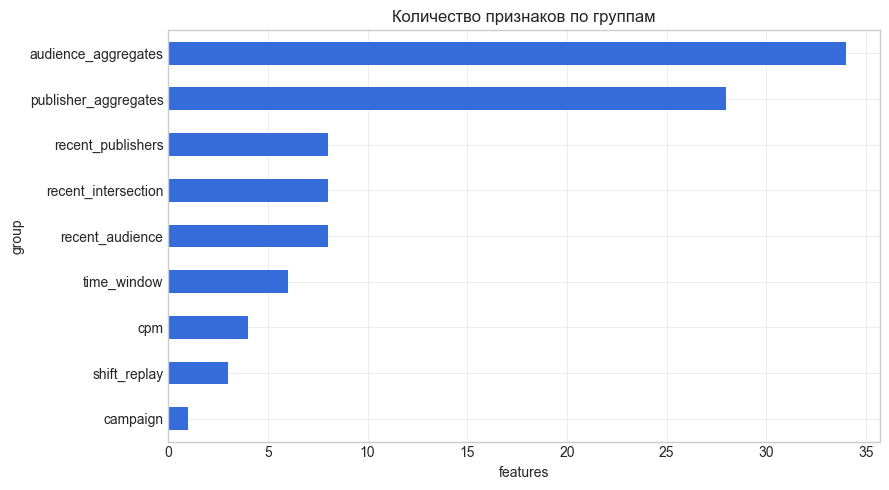

In [6]:
feature_group_counts.sort_values().plot(kind='barh', figsize=(9, 5))
plt.title('Количество признаков по группам')
plt.xlabel('features')
plt.tight_layout()

### 4.1. Что именно происходит при предобработке

Ниже таблица с логикой генерации признаков. Она нужна для защиты: по ней видно, что большая часть работы была сделана до обучения модели, а ML получает уже осмысленную кампанийную матрицу.

In [ ]:
preprocessing_steps = pd.DataFrame([
    {
        'stage': 'campaign parameters',
        'source': 'validate.tsv',
        'generated_features': 'cpm, log_cpm, window_length, hour_of_day, publisher_count, audience_size',
        'why_important': 'задают цену, длительность и масштаб кампании; напрямую влияют на шанс выиграть аукцион и набрать показы',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'audience aggregation',
        'source': 'users.tsv + history.tsv + user_ids from validate.tsv',
        'generated_features': 'средний возраст/пол/город, user_impressions, active_hours, publishers, user_cpm_*',
        'why_important': 'одинаковая кампания по-разному работает на активной и неактивной аудитории; история пользователей показывает вероятность будущих контактов',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'publisher aggregation',
        'source': 'history.tsv + publishers from validate.tsv',
        'generated_features': 'pub_impressions, pub_users, pub_cpm_mean/median/p75/p90/p95, pub_hour_*',
        'why_important': 'площадки отличаются объемом трафика и уровнем конкуренции по cpm; квантили ставок помогают понять силу нашей ставки',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'recent activity window',
        'source': 'history.tsv before campaign start',
        'generated_features': 'recent_31d_audience_*, recent_31d_publishers_*',
        'why_important': 'тестовый месяц находится в будущем, поэтому недавняя активность ближе к прогнозируемому периоду, чем вся история целиком',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'audience-publisher intersection',
        'source': 'history.tsv filtered by campaign users and publishers',
        'generated_features': 'recent_31d_intersection_impressions/sessions/win_rate/active_user_share',
        'why_important': 'самый близкий табличный аналог будущих показов: именно эти пользователи на именно этих площадках',
        'used_in_model': 'features_validate.tsv',
    },
    {
        'stage': 'shift replay simulation',
        'source': 'history.tsv + validate.tsv shifted by 31 days',
        'generated_features': 'shift_replay_at_least_one/two/three',
        'why_important': 'использует правила аукциона и сессий напрямую, поэтому является сильным базовым прогнозом',
        'used_in_model': 'joined with features_validate.tsv before residual calibration',
    },
])
preprocessing_steps

### 4.2. Как признаки попадают в модель

`features_validate.tsv` содержит все табличные признаки, созданные на этапе предобработки. Затем к нему добавляются три replay-колонки из `shift_replay_predictions.tsv`. Полученная матрица `features_full` используется как вход `X` для residual-модели.

In [ ]:
model_input_summary = pd.DataFrame([
    {'object': 'features_validate.tsv', 'rows': len(features), 'columns': features.shape[1], 'role': 'созданные табличные признаки кампаний'},
    {'object': 'shift_replay_predictions.tsv', 'rows': len(shift_replay), 'columns': shift_replay.shape[1], 'role': 'симуляционный baseline как признаки'},
    {'object': 'features_full', 'rows': len(features_full), 'columns': features_full.shape[1], 'role': 'финальный вход X для ML-калибровки'},
    {'object': 'validate_answers.tsv', 'rows': len(answers), 'columns': answers.shape[1], 'role': 'целевая переменная y'},
])
model_input_summary

## 5. Почему replay-бейзлайн сильный

`shift_replay` берет кампанию из validate, сдвигает ее окно на 31 день назад и проигрывает ее на исторических показах:

- фильтрует события по пользователям аудитории;
- фильтрует события по выбранным площадкам;
- сравнивает `cpm` кампании с историческим `cpm` конкурента;
- внутри сессий считает вероятность хотя бы одного выигрыша;
- агрегирует вероятности до `at_least_one/two/three`.

Это не обучаемая модель, а симуляция правил задачи на прошлом месяце. Поэтому она является более сильной отправной точкой, чем обычный табличный ML.

## 6. ML как калибровка replay

Обычная ML-модель на 1008 строках легко переобучается. Поэтому финальная схема не предсказывает таргет с нуля, а учит поправку к replay-прогнозу.

Формула:

`residual = log(answer + eps) - log(shift_replay + eps)`

`prediction = exp(log(shift_replay + eps) + shrink * residual_model(features_full)) - eps`

`features_full` здесь означает `features_validate.tsv + shift_replay_predictions.tsv`. `shrink` ограничивает силу ML-поправки. Это важно, потому что полная поправка может переисправлять хороший replay-бейзлайн.

In [7]:
def read_prediction(path: str) -> pd.DataFrame | None:
    file_path = ROOT / path
    if not file_path.exists():
        return None
    return pd.read_csv(file_path, sep='\t')[TARGET_COLUMNS]

prediction_sources = [
    ('shift_replay', 'shift_replay_predictions.tsv', 'simulation baseline'),
    ('ml_time_saved', 'ml_baseline_time_predictions.tsv', 'older saved prediction'),
    ('catboost_optuna_saved', 'catboost_optuna_predictions.tsv', 'older saved prediction'),
    ('residual_calibration_oof', 'replay_calibrated_predictions.tsv', 'OOF residual calibration'),
]

rows = []
for name, filename, kind in prediction_sources:
    pred = read_prediction(filename)
    if pred is None:
        continue
    rows.append({
        'approach': name,
        'file': filename,
        'kind': kind,
        'metric': get_smoothed_mean_log_accuracy_ratio(answers, pred),
    })

metric_table = pd.DataFrame(rows).sort_values('metric').reset_index(drop=True)
baseline_metric = metric_table.loc[metric_table['approach'] == 'shift_replay', 'metric'].iloc[0]
metric_table['delta_vs_shift_replay'] = metric_table['metric'] - baseline_metric
metric_table['relative_change_%'] = 100 * metric_table['delta_vs_shift_replay'] / baseline_metric
metric_table

,approach,file,kind,metric,delta_vs_shift_replay,relative_change_%
0,catboost_optuna_saved,catboost_optuna_predictions.tsv,older saved prediction,7.83,-3.65,-31.794425
1,ml_time_saved,ml_baseline_time_predictions.tsv,older saved prediction,8.28,-3.20,-27.874564
2,residual_calibration_oof,replay_calibrated_predictions.tsv,OOF residual calibration,11.18,-0.30,-2.613240
3,shift_replay,shift_replay_predictions.tsv,simulation baseline,11.48,0.00,0.000000


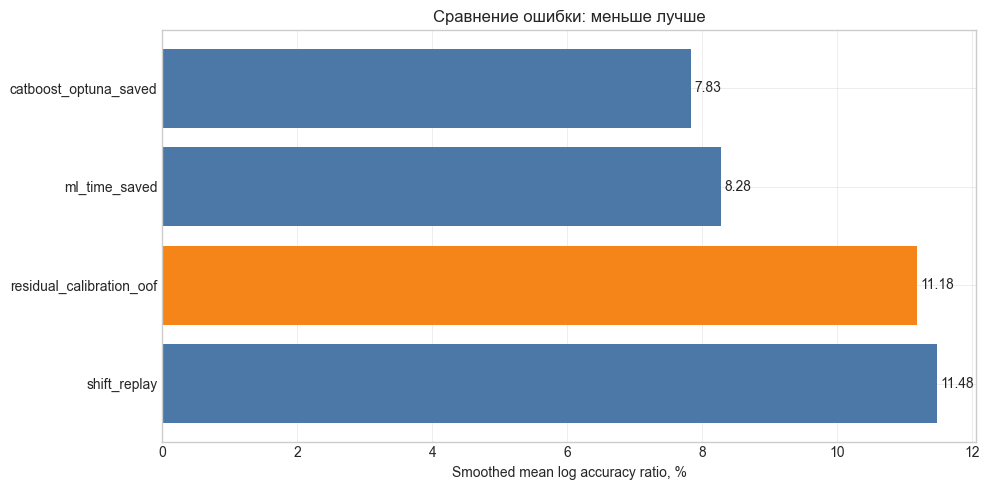

In [8]:
plot_table = metric_table.sort_values('metric', ascending=False)
colors = ['#4C78A8' if name != 'residual_calibration_oof' else '#F58518' for name in plot_table['approach']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_table['approach'], plot_table['metric'], color=colors)
ax.set_title('Сравнение ошибки: меньше лучше')
ax.set_xlabel('Smoothed mean log accuracy ratio, %')
for i, value in enumerate(plot_table['metric']):
    ax.text(value + 0.05, i, f'{value:.2f}', va='center')
plt.tight_layout()

## 7. Изменение ошибки по каждому таргету

In [9]:
def per_target_metric(pred: pd.DataFrame) -> dict[str, float]:
    return {
        target: 100 * (np.exp(get_smoothed_log_mape_column_value(pred[target], answers[target], EPSILON)) - 1)
        for target in TARGET_COLUMNS
    }

target_rows = []
for name, filename, kind in prediction_sources:
    pred = read_prediction(filename)
    if pred is None:
        continue
    for target, metric in per_target_metric(pred).items():
        target_rows.append({'approach': name, 'target': target, 'metric': metric})

target_metric_table = pd.DataFrame(target_rows)
target_metric_table.pivot(index='approach', columns='target', values='metric').round(3)

target,at_least_one,at_least_three,at_least_two
approach,,,
catboost_optuna_saved,9.594,6.036,7.885
ml_time_saved,9.857,6.773,8.223
residual_calibration_oof,14.363,8.701,10.556
shift_replay,15.002,8.731,10.802


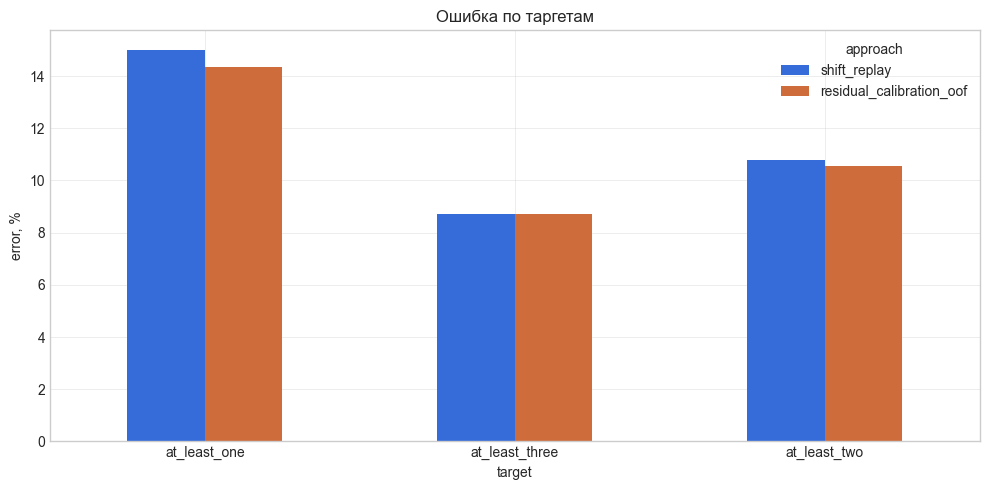

In [10]:
pivot = target_metric_table.pivot(index='target', columns='approach', values='metric')
selected = [c for c in ['shift_replay', 'residual_calibration_oof'] if c in pivot.columns]
pivot[selected].plot(kind='bar', figsize=(10, 5))
plt.title('Ошибка по таргетам')
plt.ylabel('error, %')
plt.xticks(rotation=0)
plt.tight_layout()

## 8. Что модель считает важным

Ниже обучается консервативный CatBoost для residual-калибровки. Важности признаков нужны не для финального скоринга, а для объяснения: какие группы признаков используются при поправке replay.

In [11]:
base_prediction = shift_replay.rename(columns={
    'shift_replay_at_least_one': 'at_least_one',
    'shift_replay_at_least_two': 'at_least_two',
    'shift_replay_at_least_three': 'at_least_three',
})[TARGET_COLUMNS]

residual_target = transform_target(answers) - transform_target(base_prediction)

importance_model = MultiOutputRegressor(CatBoostRegressor(
    iterations=350,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=10.0,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
))
importance_model.fit(features_full, residual_target)

importance = np.vstack([est.feature_importances_ for est in importance_model.estimators_]).mean(axis=0)
importance_df = (
    pd.DataFrame({'feature': features_full.columns, 'importance': importance})
    .assign(group=lambda df: df['feature'].map(feature_group))
    .sort_values('importance', ascending=False)
)
importance_df.head(25)

,feature,importance,group
99,shift_replay_at_least_three,8.473841,shift_replay
98,shift_replay_at_least_two,7.826553,shift_replay
97,shift_replay_at_least_one,5.736847,shift_replay
78,recent_31d_audience_win_rate,4.498312,recent_audience
94,recent_31d_intersection_win_rate,3.579770,recent_intersection
3,hour_end,3.115810,time_window
5,log_window_length,2.846351,time_window
7,end_hour_of_day,2.016990,time_window
2,hour_start,2.016824,time_window
19,audience_city_id_max,1.985804,audience_aggregates


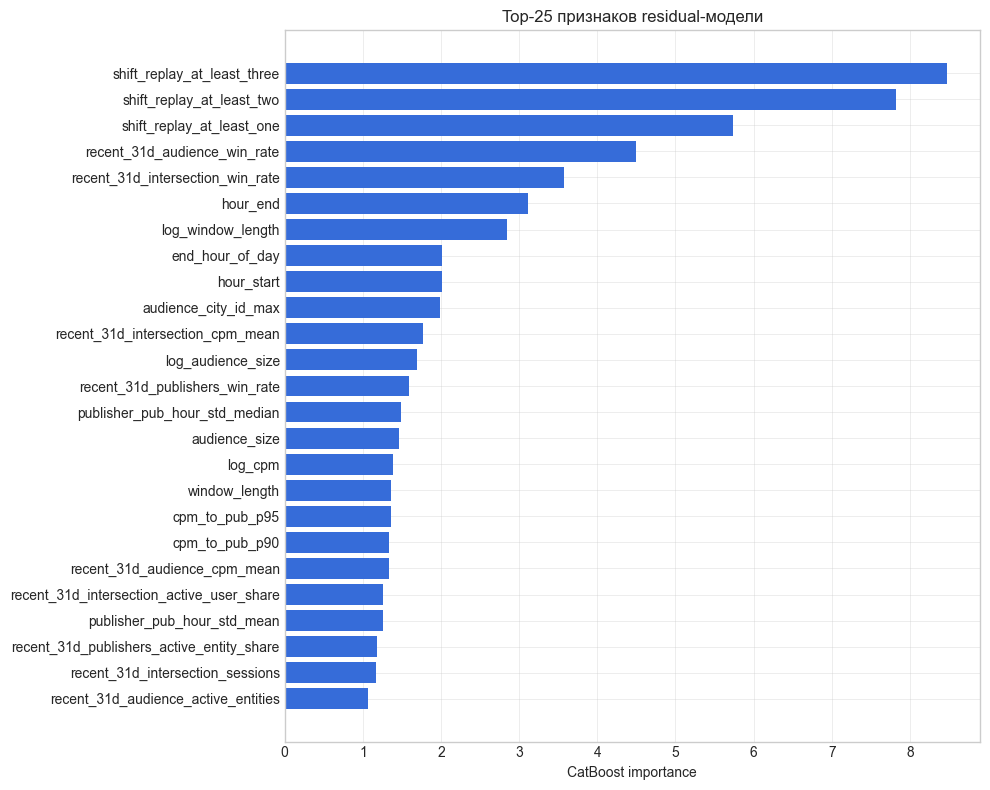

In [12]:
top = importance_df.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top['feature'], top['importance'])
ax.set_title('Top-25 признаков residual-модели')
ax.set_xlabel('CatBoost importance')
plt.tight_layout()

,group,importance
7,shift_replay,22.037240
0,audience_aggregates,18.293497
3,publisher_aggregates,14.163922
8,time_window,12.002229
5,recent_intersection,10.821329
4,recent_audience,10.393256
6,recent_publishers,6.114359
2,cpm,4.481770
1,campaign,1.692399


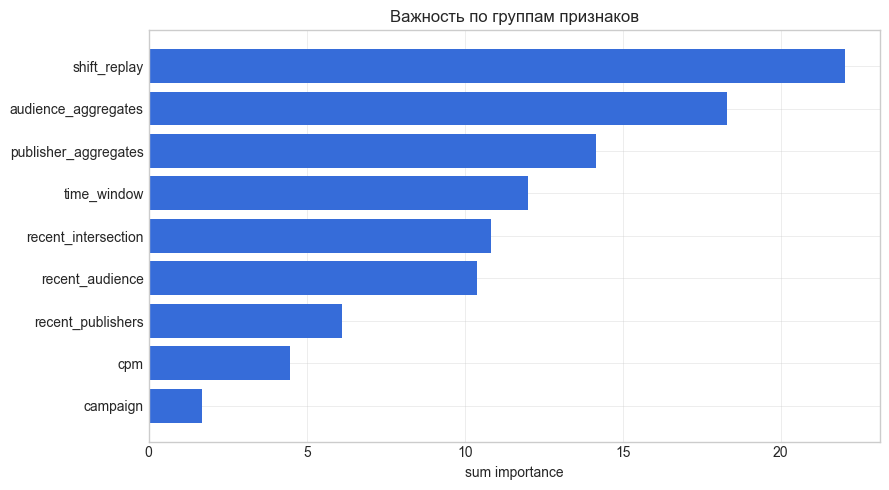

In [13]:
group_importance = importance_df.groupby('group', as_index=False)['importance'].sum().sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(group_importance['group'], group_importance['importance'])
ax.set_title('Важность по группам признаков')
ax.set_xlabel('sum importance')
plt.tight_layout()
group_importance.sort_values('importance', ascending=False)

## 9. Actual vs predicted

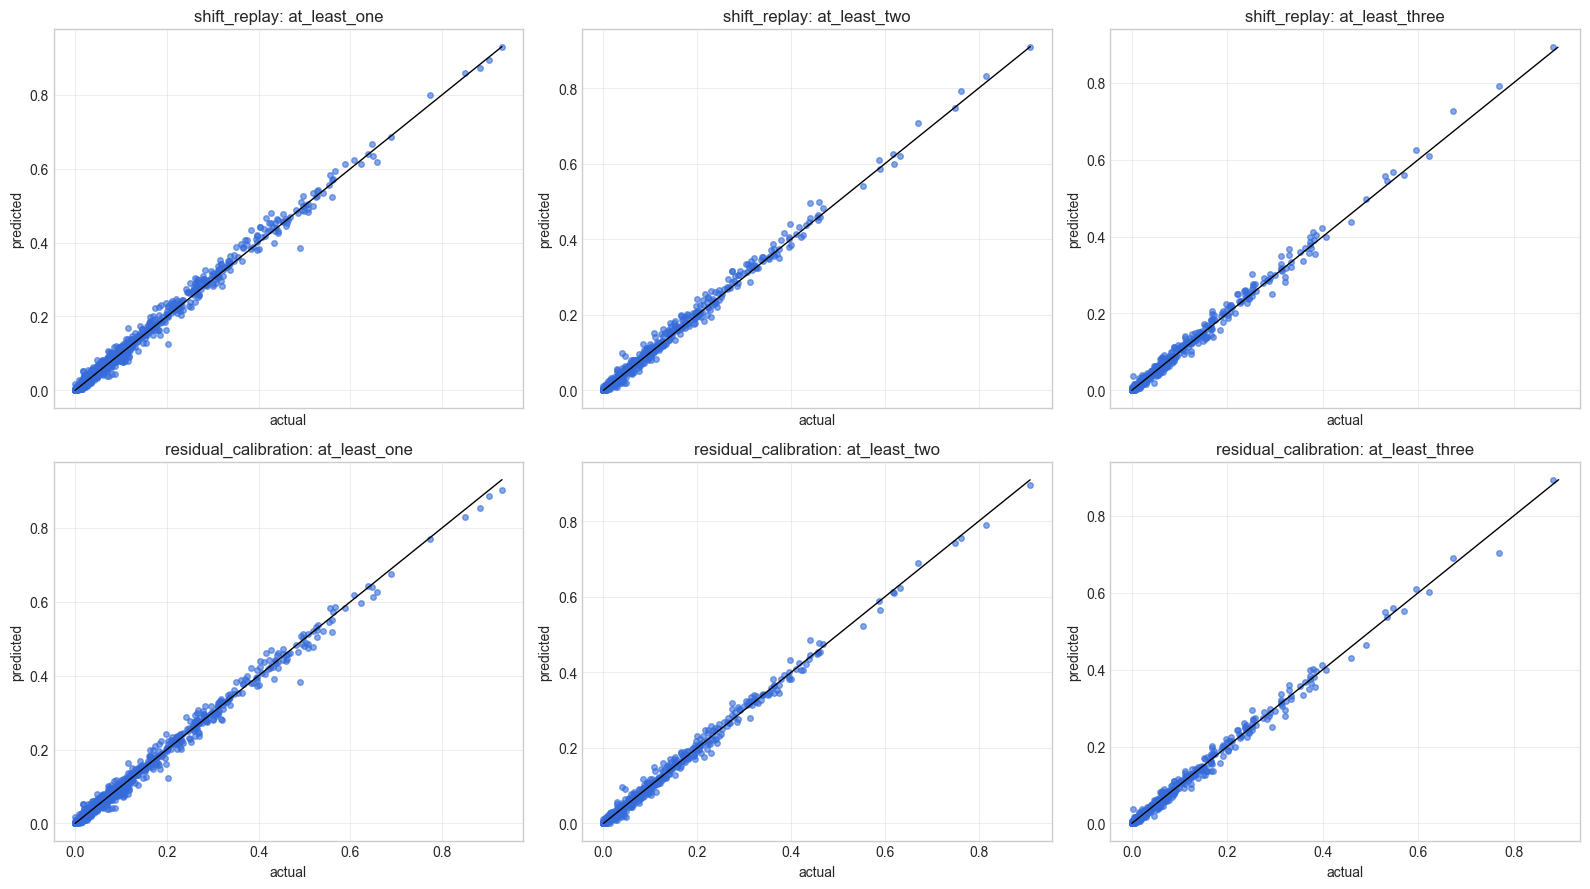

In [14]:
calibrated = read_prediction('replay_calibrated_predictions.tsv')
shift = read_prediction('shift_replay_predictions.tsv')

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex='col', sharey='col')
for col_idx, target in enumerate(TARGET_COLUMNS):
    for row_idx, (title, pred) in enumerate([('shift_replay', shift), ('residual_calibration', calibrated)]):
        ax = axes[row_idx, col_idx]
        ax.scatter(answers[target], pred[target], s=16, alpha=0.6)
        limit = max(answers[target].max(), pred[target].max())
        ax.plot([0, limit], [0, limit], color='black', linewidth=1)
        ax.set_title(f'{title}: {target}')
        ax.set_xlabel('actual')
        ax.set_ylabel('predicted')

plt.tight_layout()

## 10. Итоговая схема решения

1. Восстанавливаем сессии пользователей по правилу разрыва в 6 часов.
2. Строим кампанийные признаки: параметры кампании, аудитория, площадки, свежая история, пересечения аудитории и площадок.
3. Считаем `shift_replay`: симулируем кампанию на предыдущем месяце с учетом правил аукциона.
4. Обучаем residual-модель: она предсказывает не сам ответ, а ошибку replay в лог-пространстве.
5. Ограничиваем силу поправки через `shrink`, чтобы не переобучиться на 1008 строках.

Главный результат: residual-калибровка улучшает replay-бейзлайн, сохраняя интерпретируемость решения и связь с механикой задачи.